### This notebook demonstrates the post-analysis and visualisation of the PRAS results

In [1]:
import sys
import os

import calendar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import datetime as datetime
sys.path.append("src")
import numpy as np
from utility import get_shortfall_data, plot_std_error, load_scenario_data
from utility import load_eue_shortfall, get_all_info, reg_load_gen
from utility import plot_yearly_rlg_v1, seasonal_ppmm_stats,get_data_simu 
from utility import flow_result, plot_flow, plot_EUE_lgs

area_code_region = {1:"NNSW", 2:"CNSW", 3:"SNW", 4:"SNSW", 5:"WNV",
                        6:"MEL", 7:"SEV",  8:"NQ", 9:"CQ", 10:"GG",
                        11:"SQ", 12:"NSA", 13:"CSA", 14:"SESA", 15:"TAS"} 

IDIR = os.path.join(os.getcwd(), "../data", "pras_metrics_output", "shortfall_data")
figsize = (25,10)
mpl.rcParams['font.family'] = 'sans-serif'

In [41]:
def load_shortfall_error_data(scenario, IDIR):
    scen_DIR = os.path.join(IDIR, scenario)
    if scenario == "MT":
        date_run = "27-Mar-26-21-14-11"
    elif scenario == "ST":
        date_run = "27-Mar-26-21-0-57"
    elif scenario == "LT":
        date_run = "27-Mar-26-20-35-52"
        SDIR = os.path.join(os.getcwd(), "../../../../junk", "ISP_DATA")
        scen_DIR = os.path.join(SDIR, scenario)
    elif scenario == "SUM_ED":
        date_run = "14-Mar-26-15-27-7"
  
    data_file = os.path.join(scen_DIR, date_run, "pras_results.json")
    lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file, area_code_region)
    error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}
    return error_dict, shortfall_data
    

In [38]:
scenario = "LT"
print("Scenario chosen: ", scenario)
error_dict, shortfall_data = load_shortfall_error_data(scenario, IDIR)

Scenario chosen:  LT


Scenario:  ST


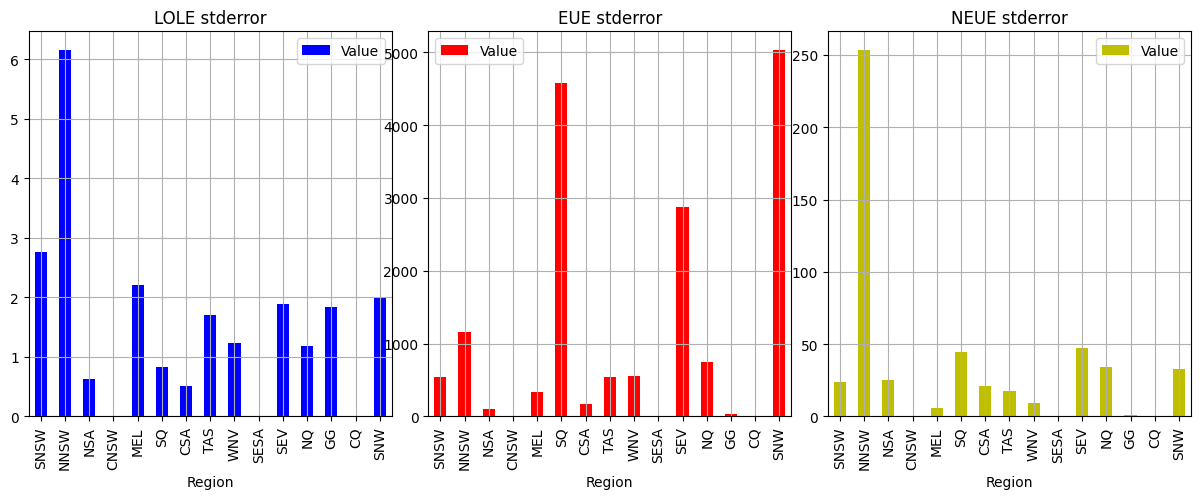

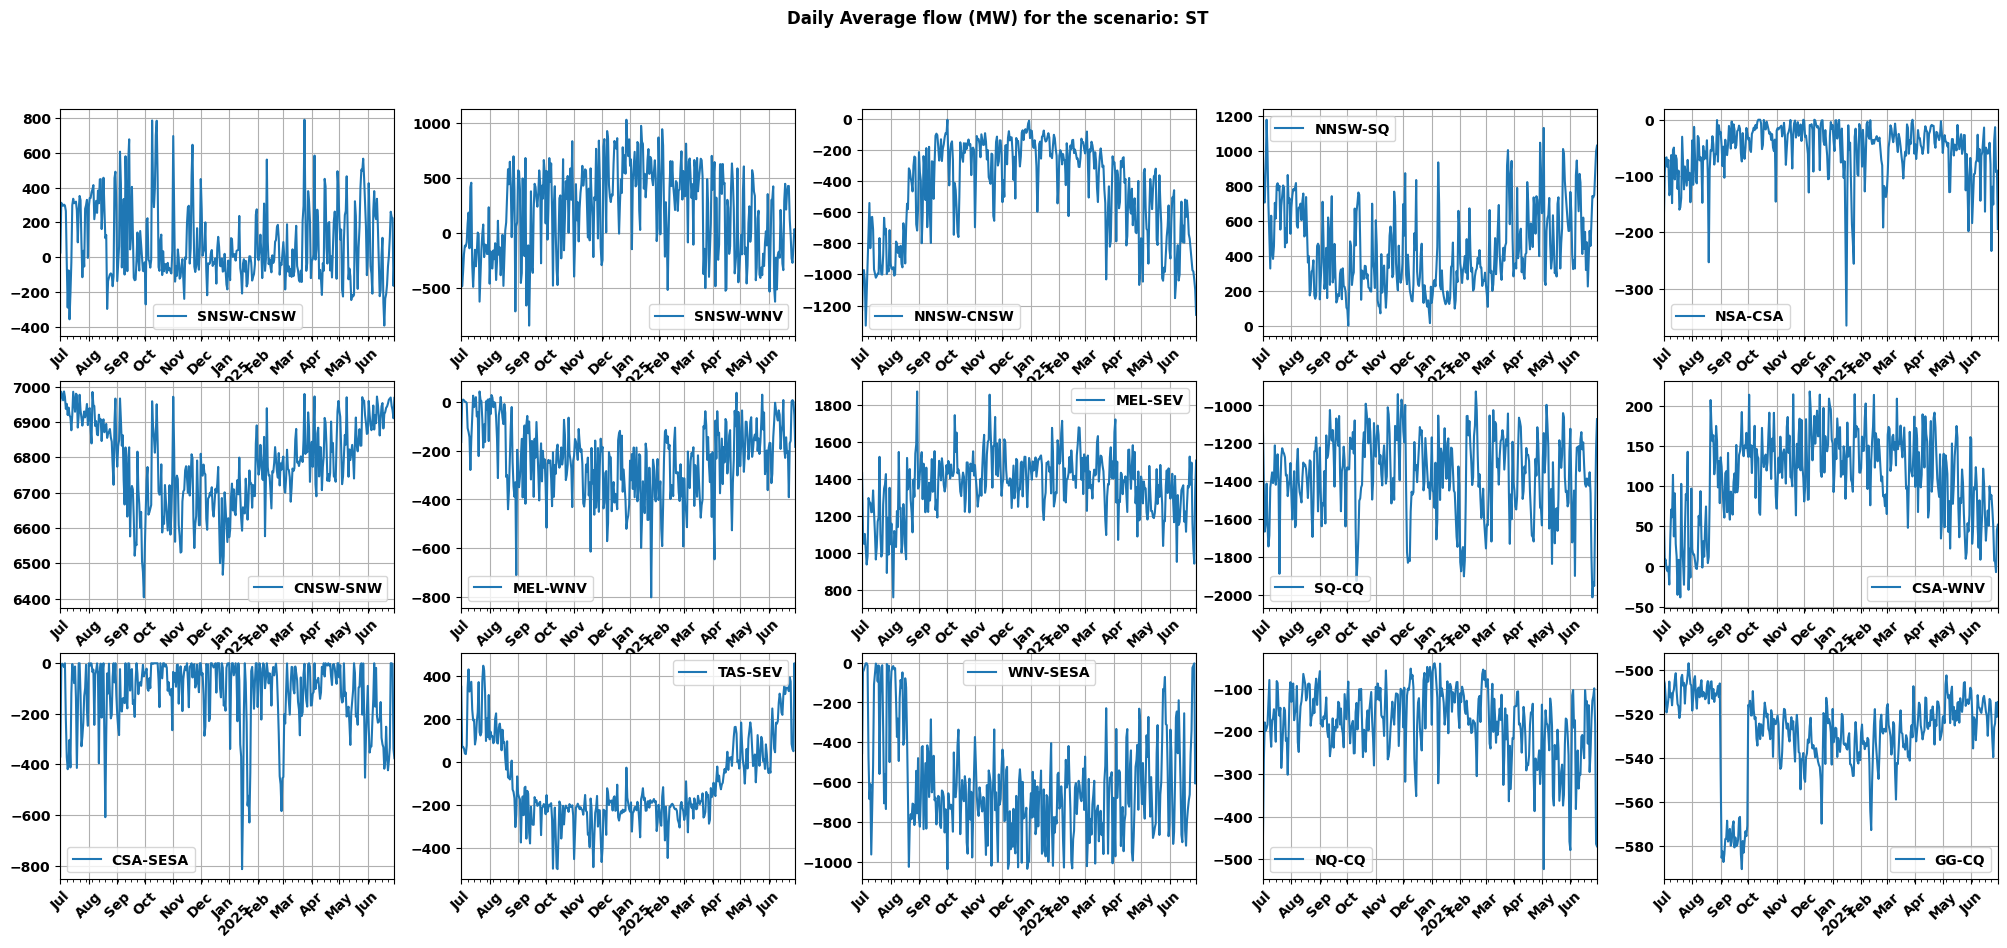

In [4]:
print("Scenario: ", scenario)
plot_std_error(error_dict)
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

Scenario:  MT


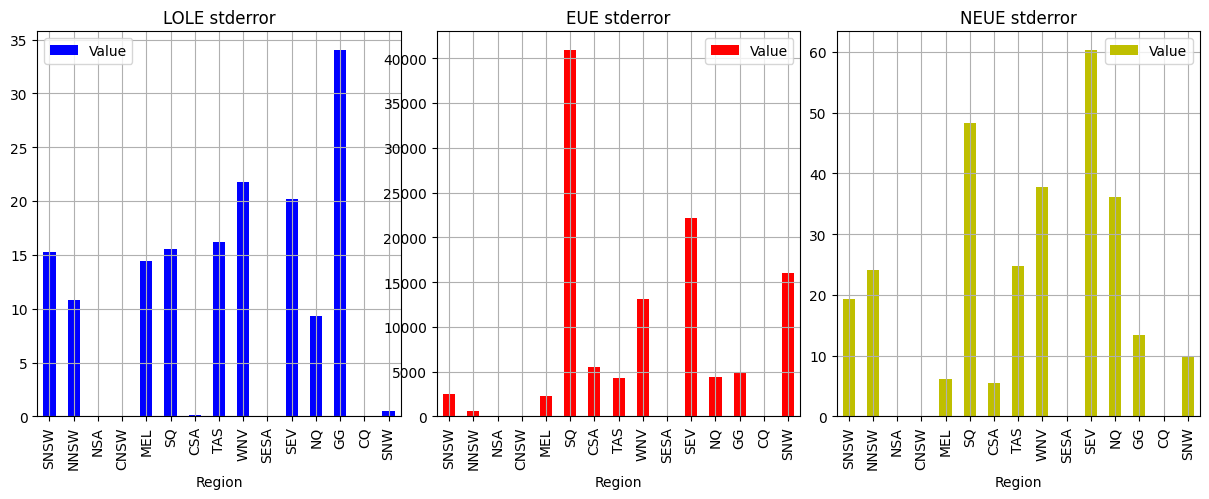

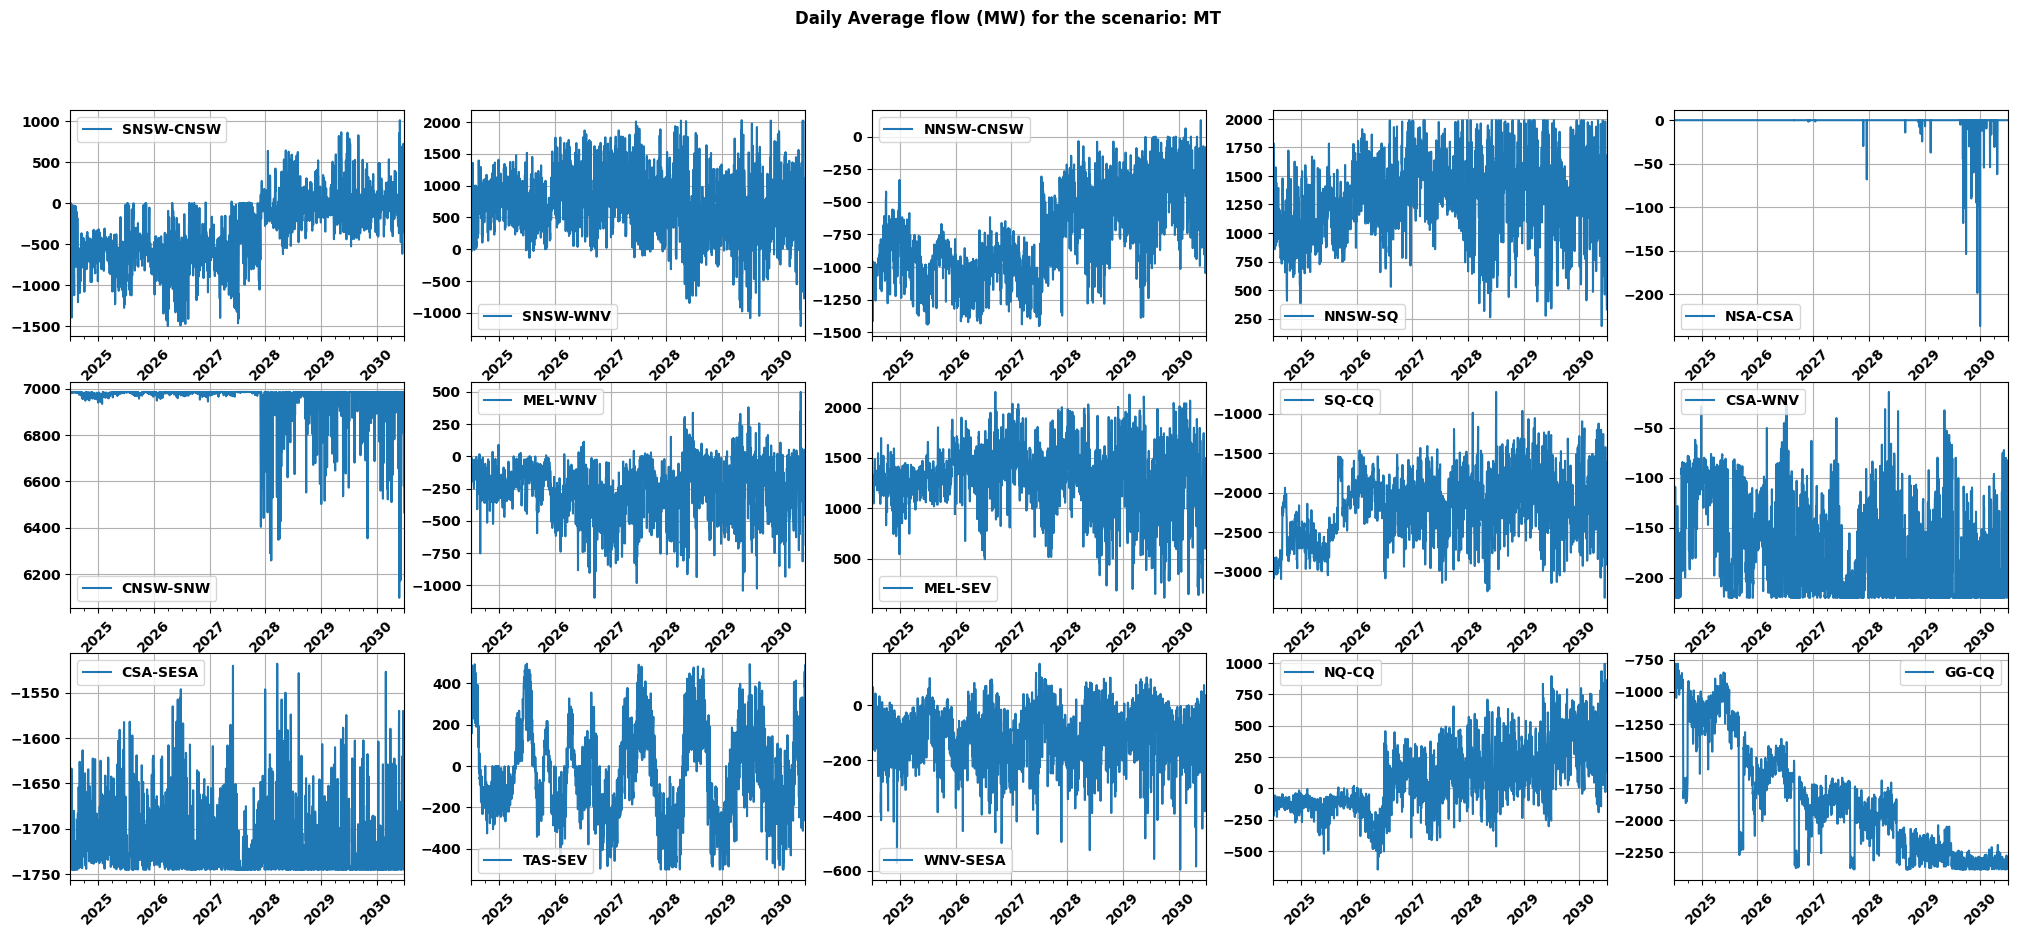

In [7]:
print("Scenario: ", scenario)
plot_std_error(error_dict)
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

Scenario:  LT


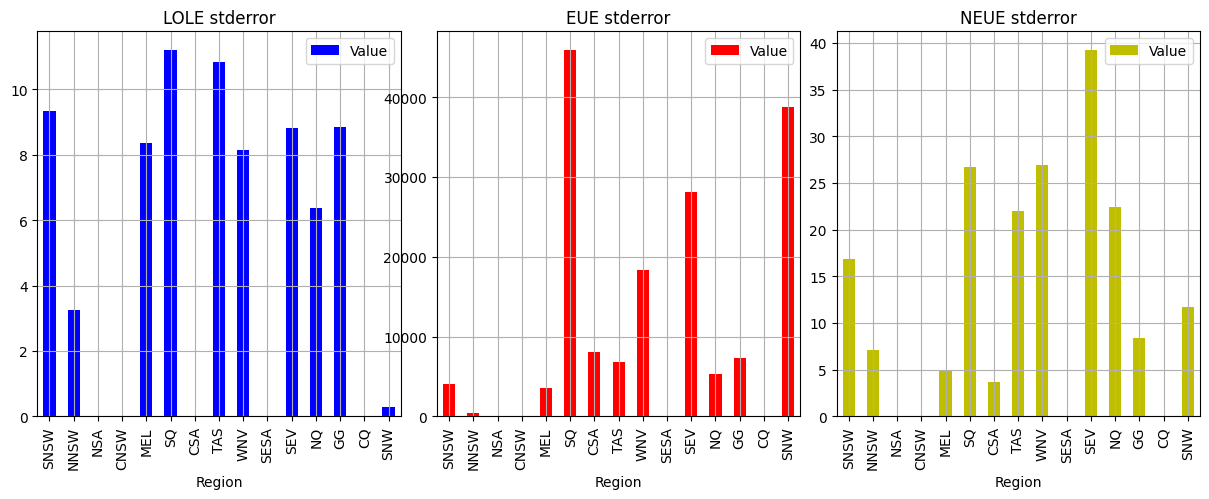

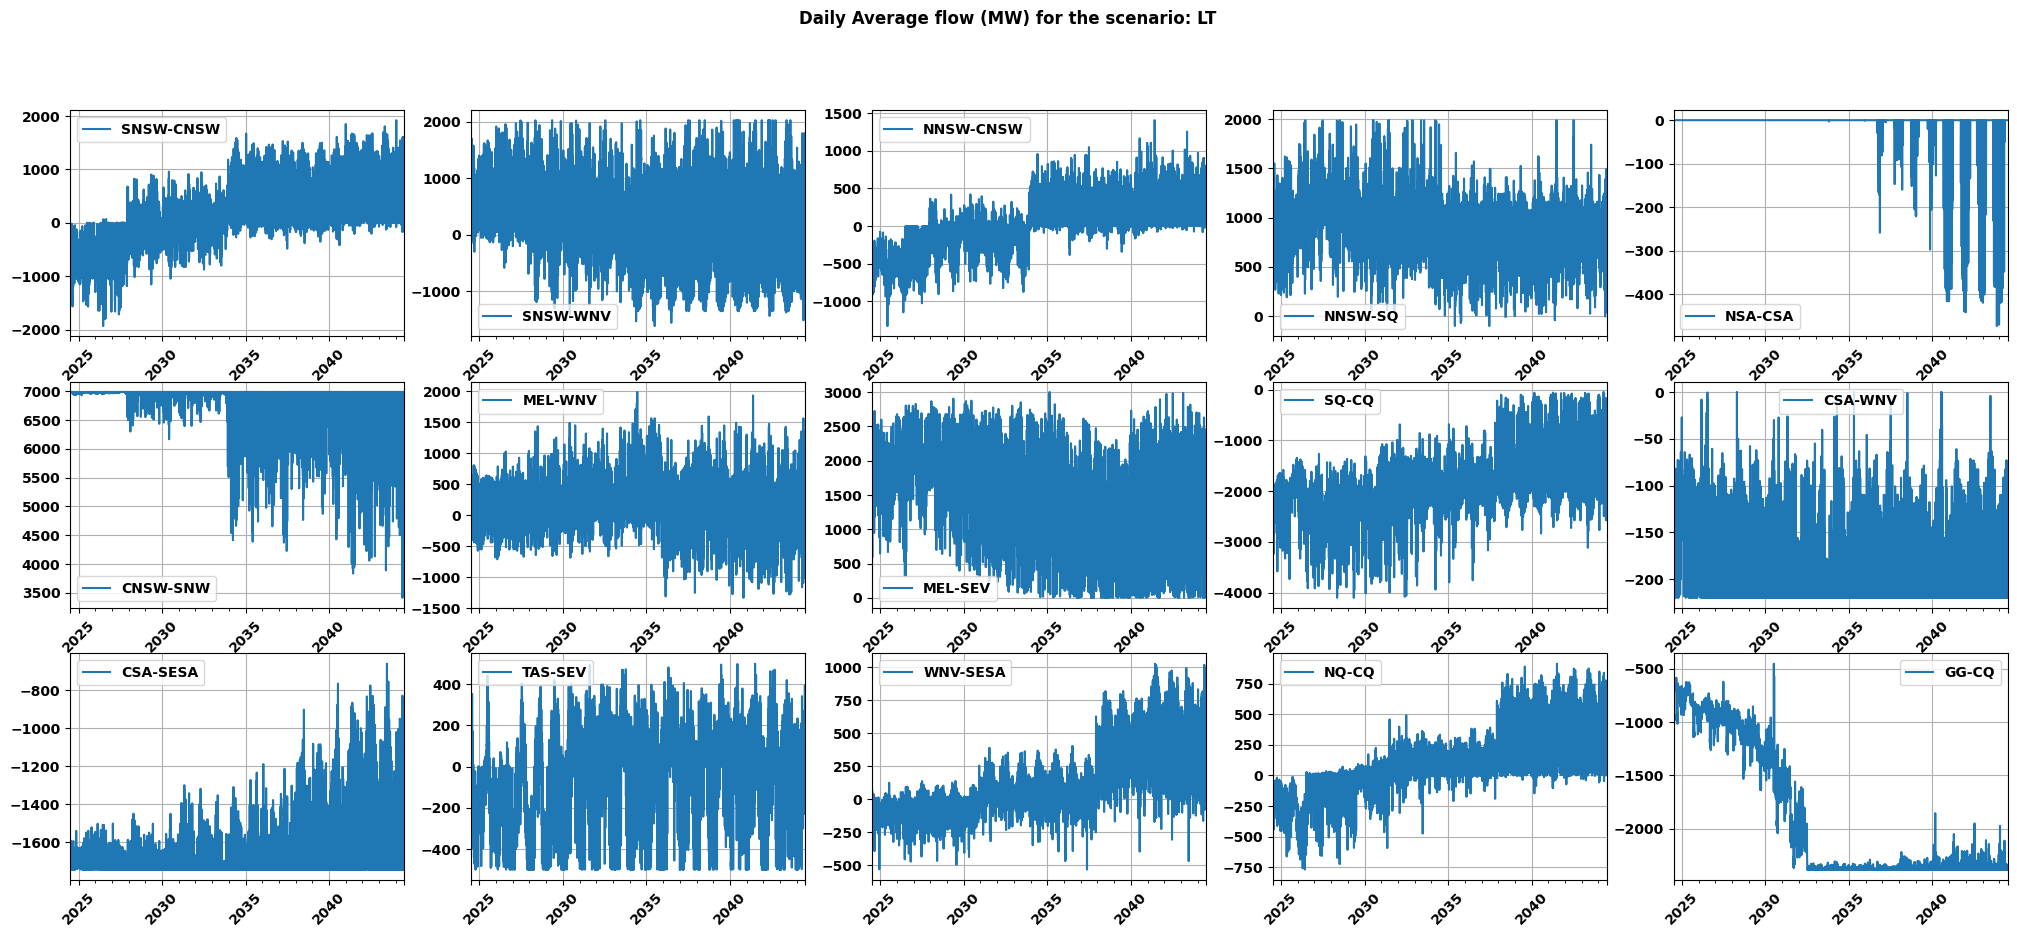

In [9]:
print("Scenario: ", scenario)
plot_std_error(error_dict)
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

scenario:  ST


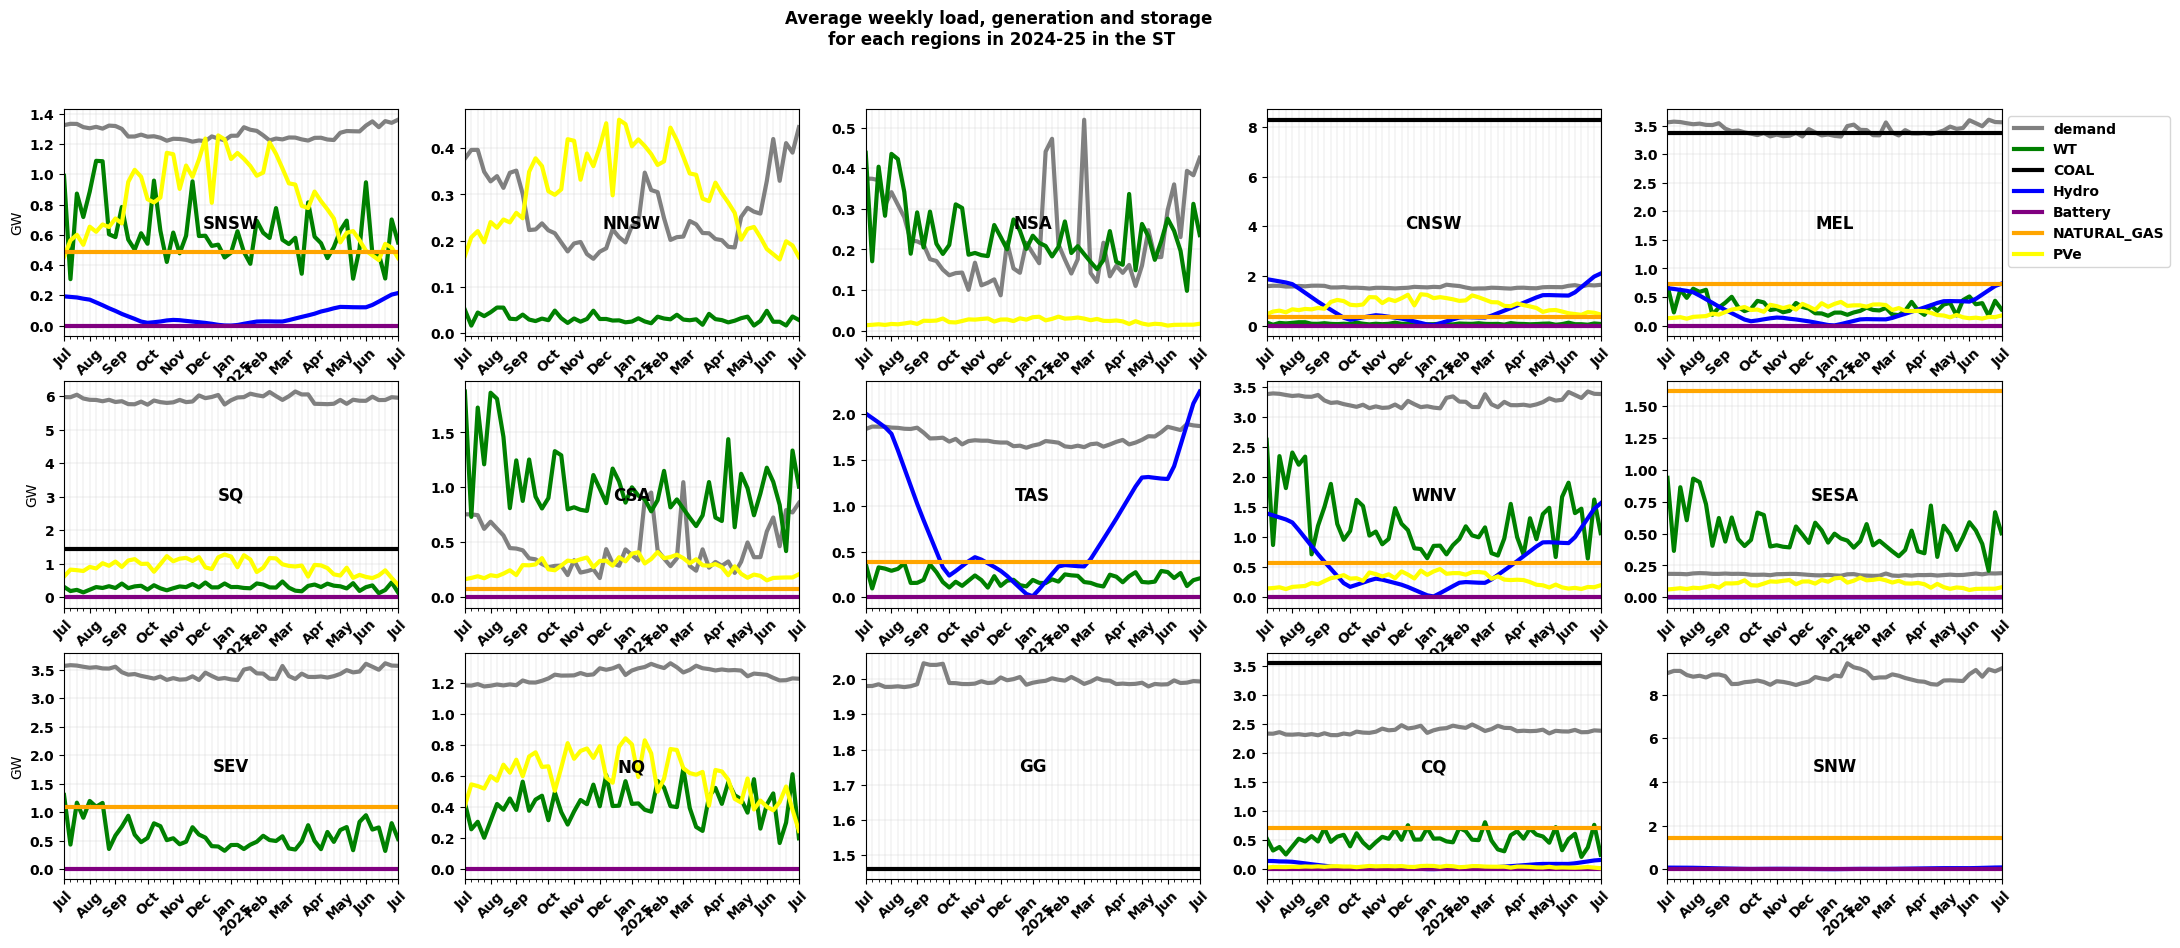

In [5]:
print("scenario: ", scenario)
resample = "weekly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, 
                   resample, scenario)

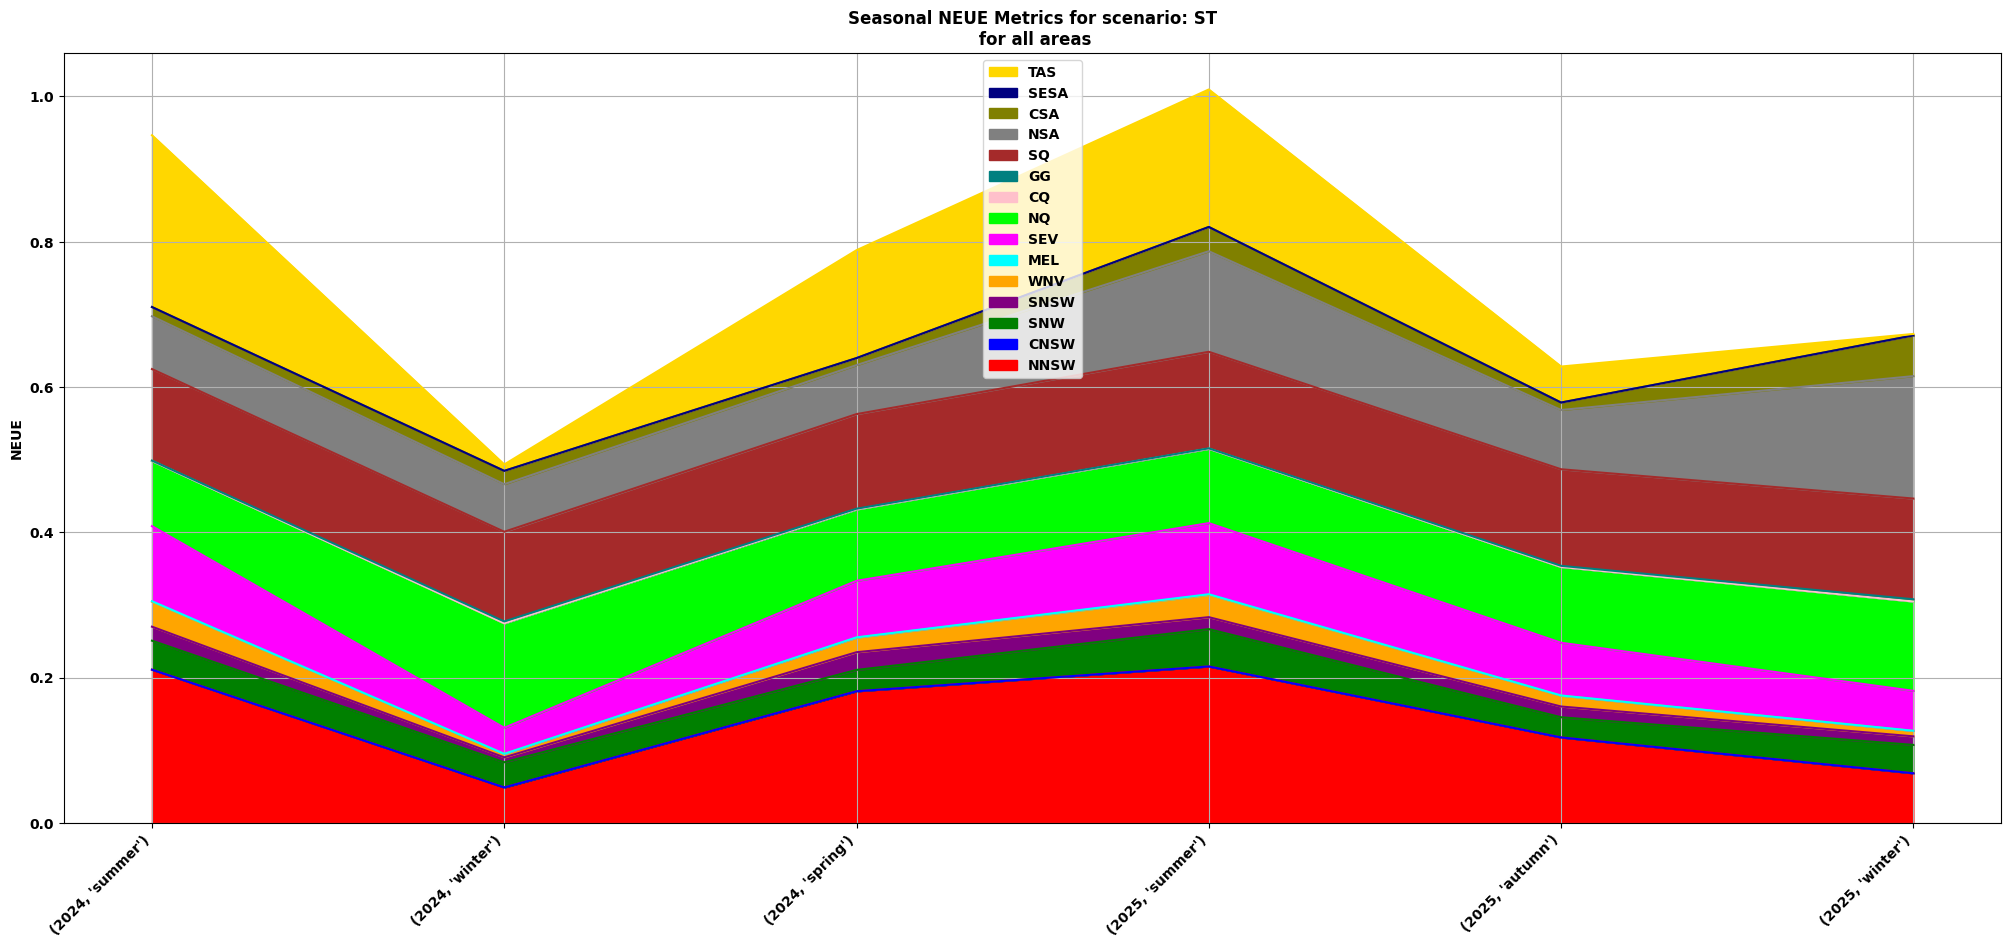

In [4]:
seasonal_data = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

scenario:  MT


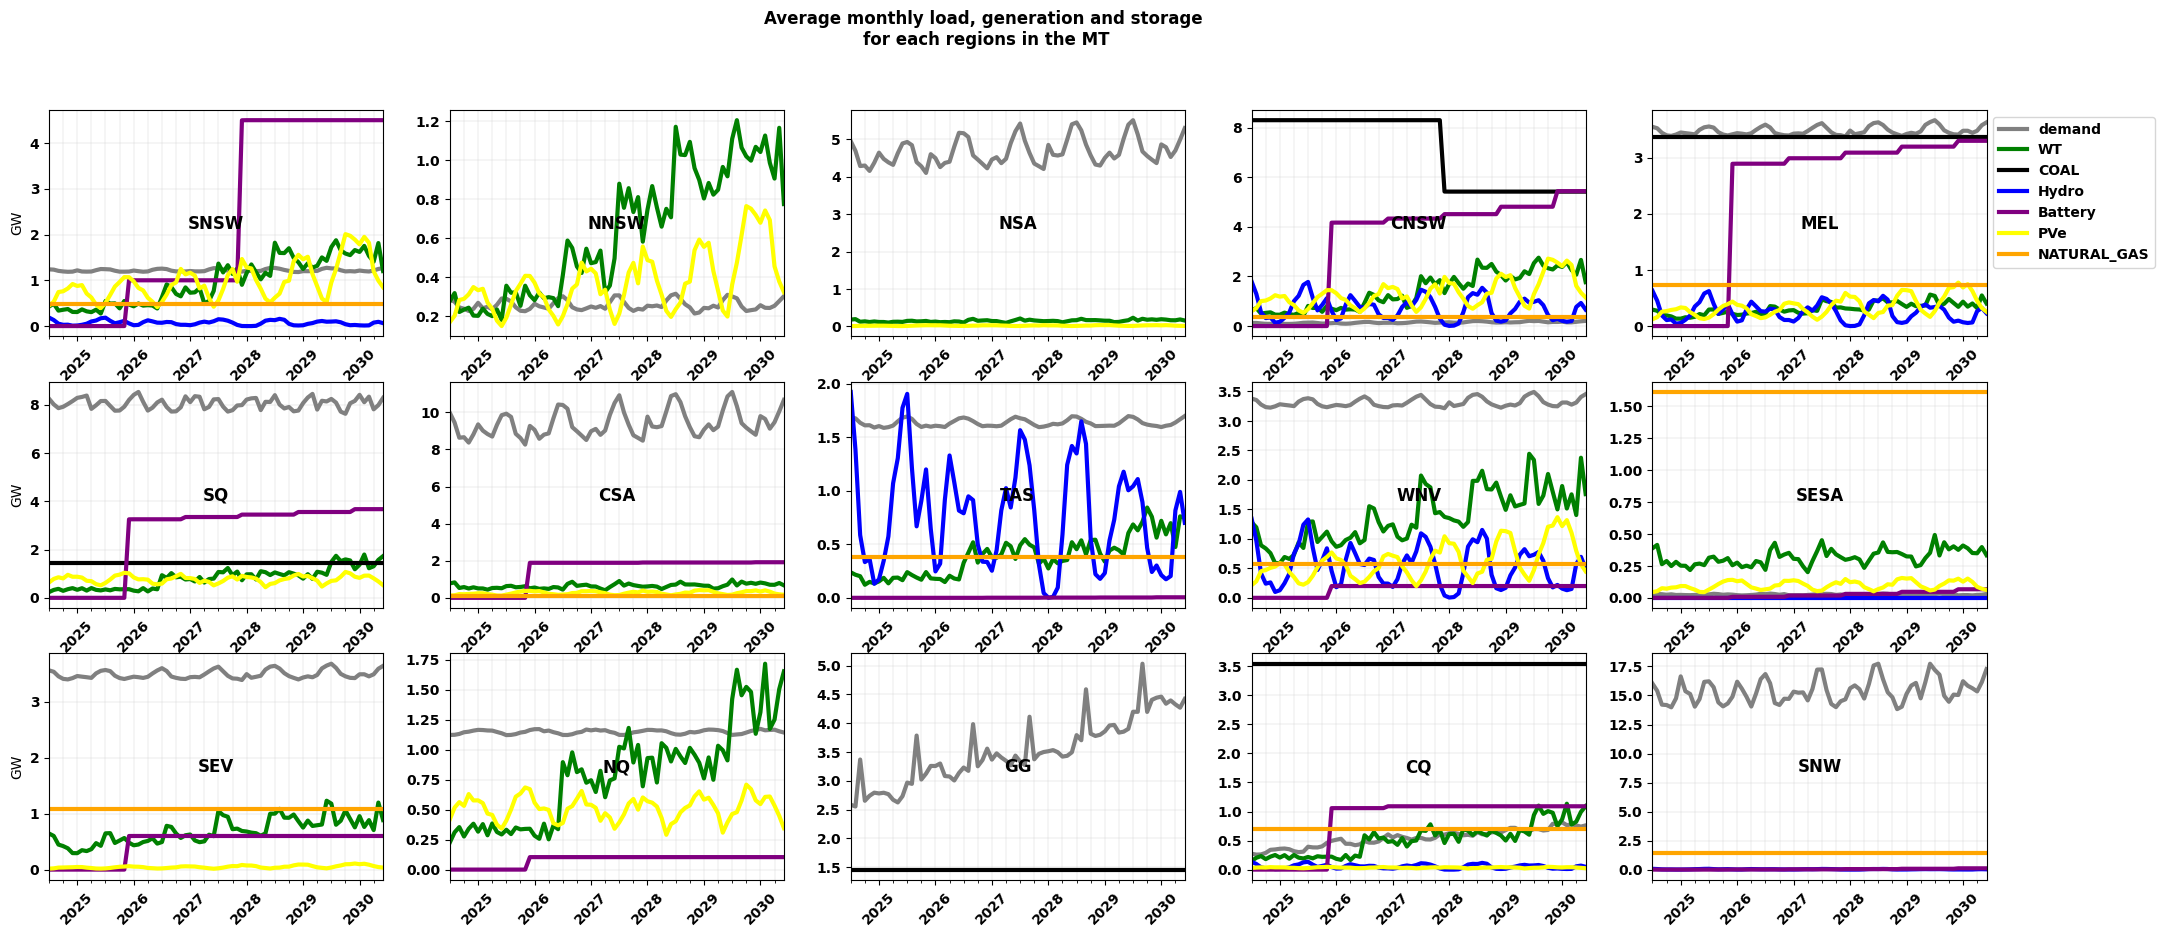

In [8]:
print("scenario: ", scenario)
resample="monthly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, resample, scenario)

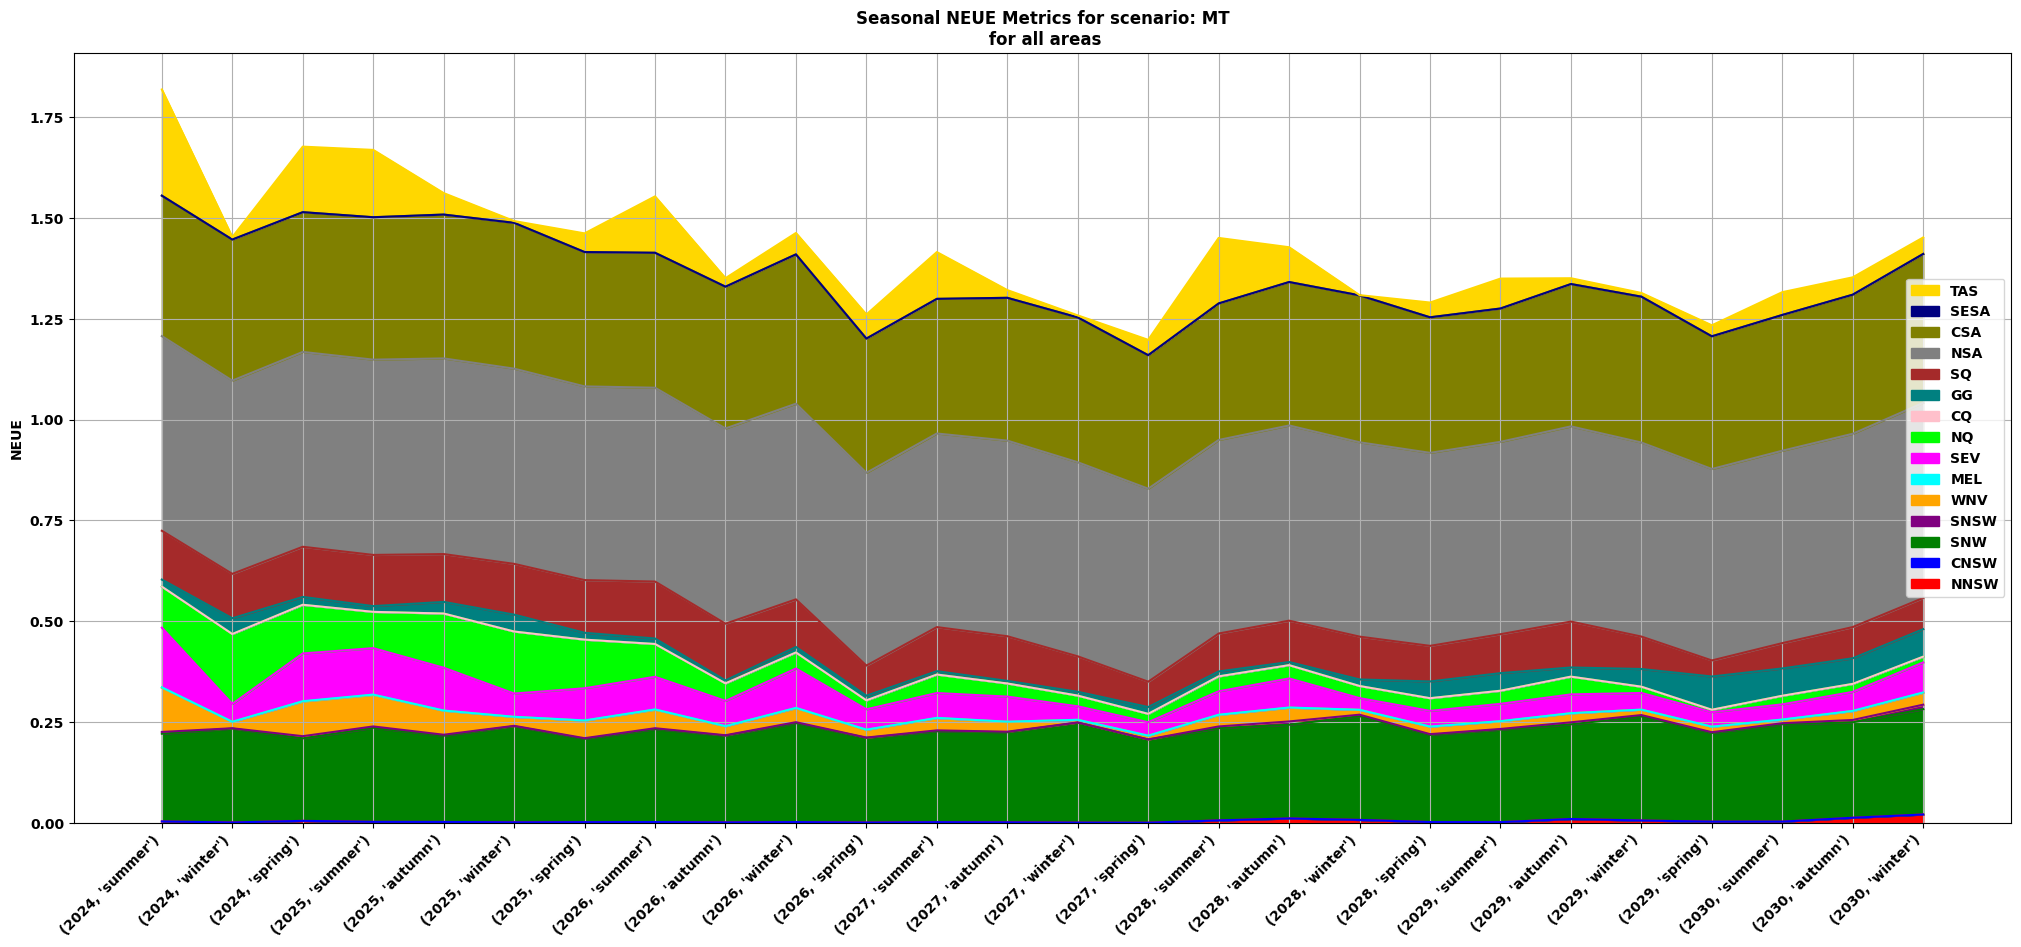

In [7]:
seasonal_data = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

scenario:  LT


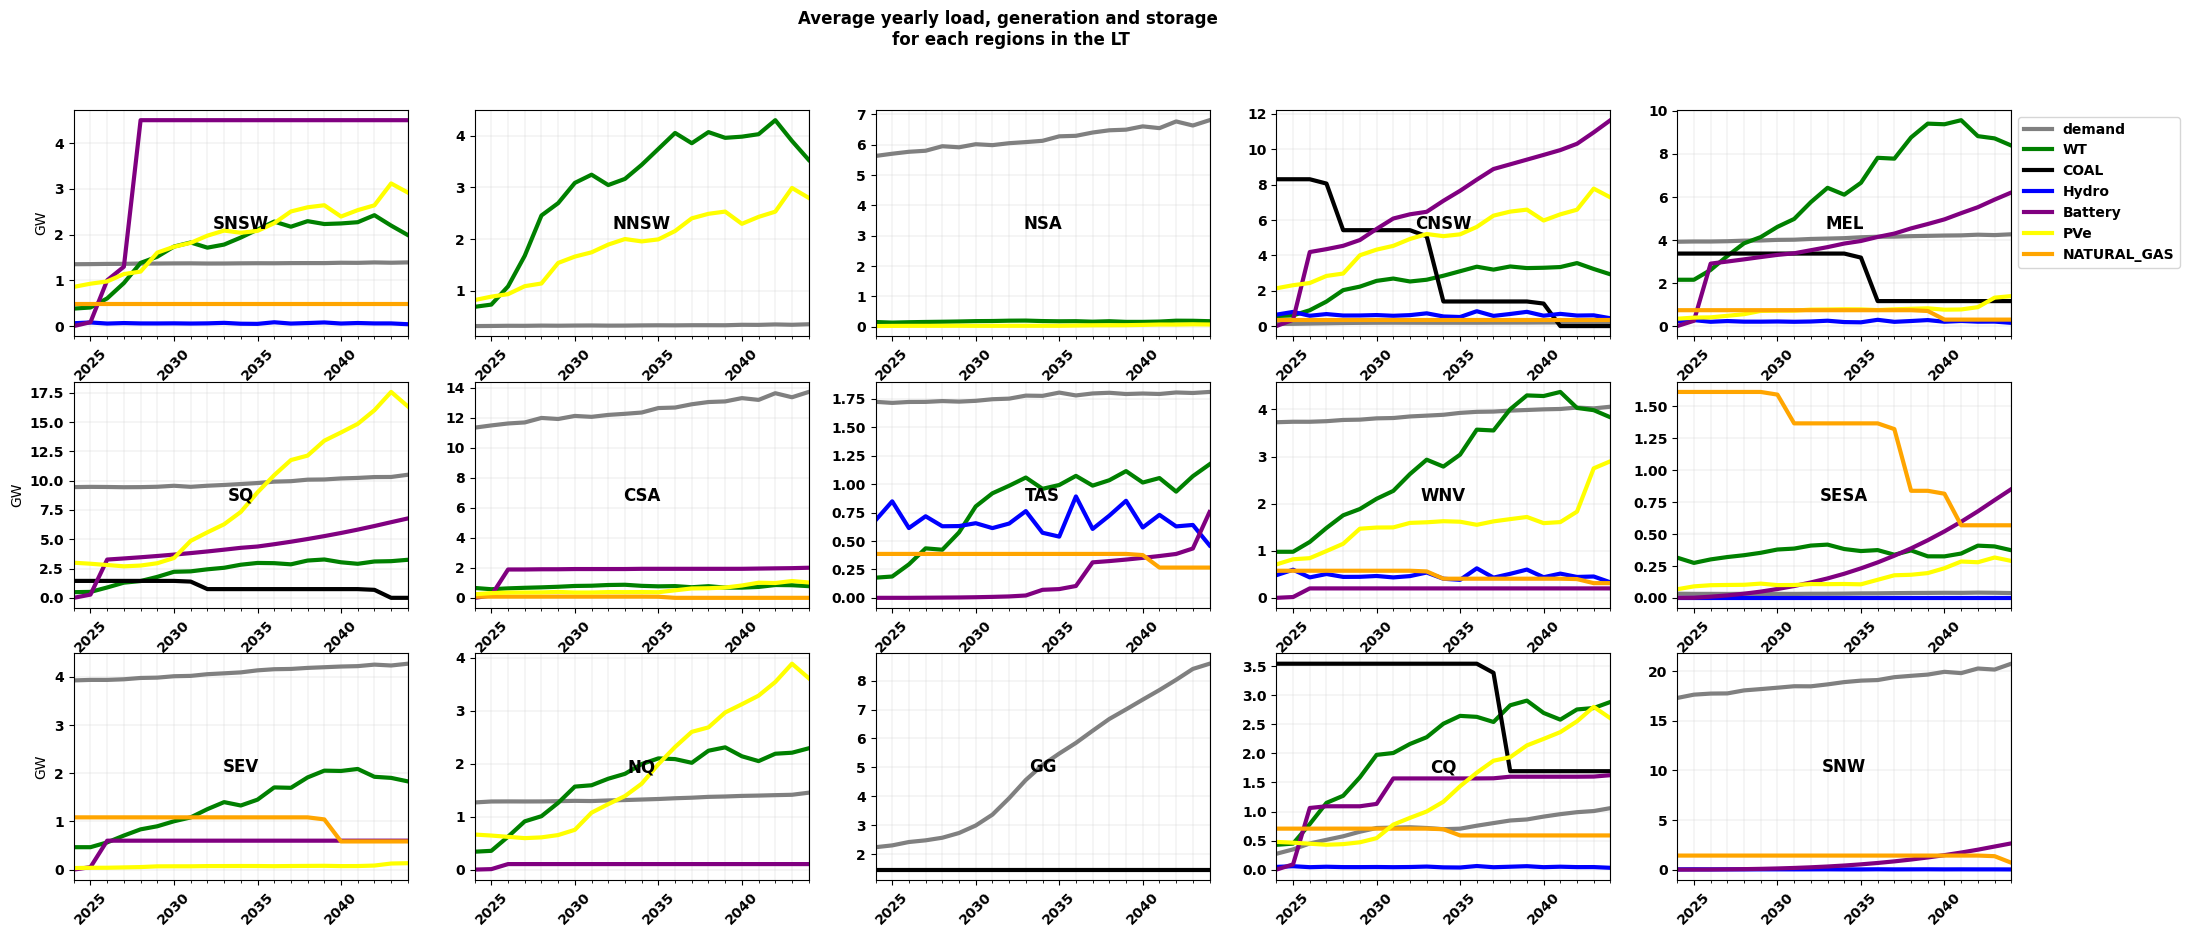

In [39]:
print("scenario: ", scenario)
resample="yearly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, resample, scenario)

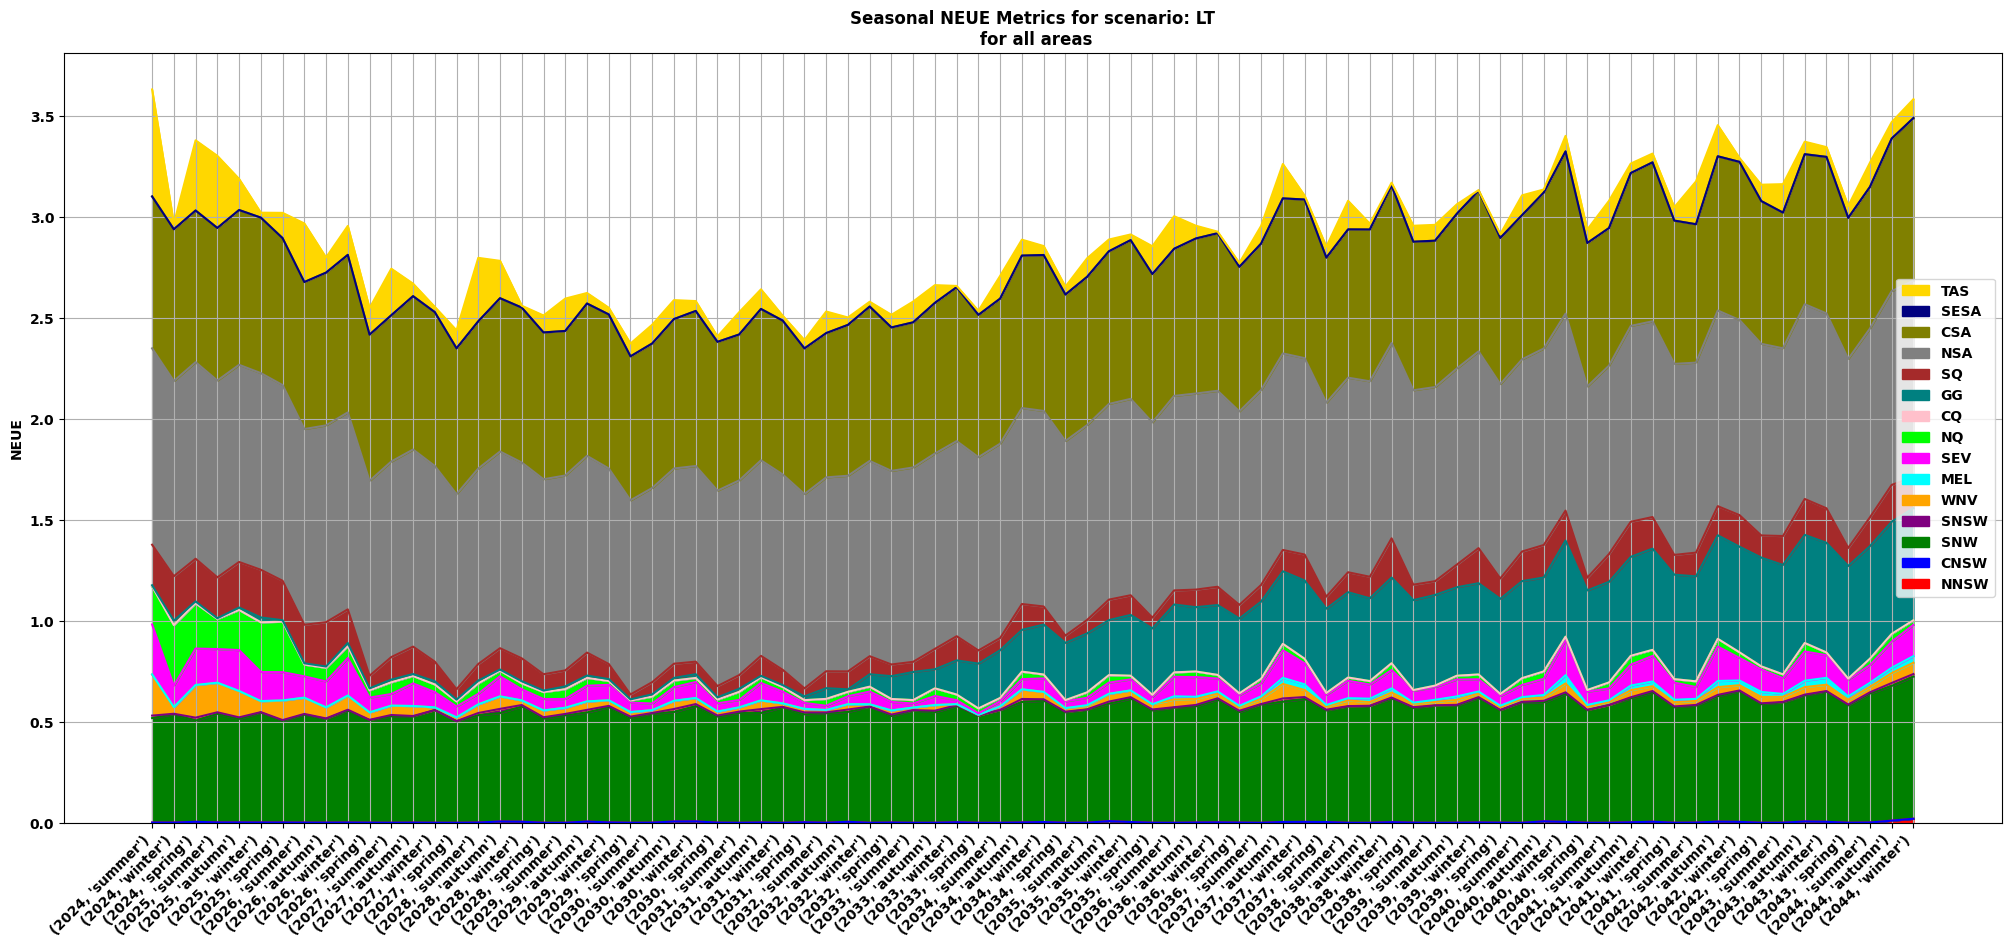

In [10]:
seasonal_data = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

In [40]:
seasonal_data

CNSW   CQ       CSA        GG       MEL      NNSW        NQ  \
timestamp season                                                                
2024      summer   0.0  0.0  0.752674  0.005486  0.001047  0.001232  0.188805   
          winter   0.0  0.0  0.752026  0.022164  0.000520  0.001019  0.300490   
          spring   0.0  0.0  0.751532  0.009164  0.000774  0.004933  0.224531   
2025      summer   0.0  0.0  0.756093  0.003566  0.000893  0.001836  0.149113   
          autumn   0.0  0.0  0.767152  0.012276  0.001047  0.001811  0.198482   
...                ...  ...       ...       ...       ...       ...       ...   
2043      winter   0.0  0.0  0.775636  0.543398  0.034051  0.004948  0.013687   
          spring   0.0  0.0  0.699120  0.558070  0.016832  0.000252  0.005144   
2044      summer   0.0  0.0  0.701895  0.557718  0.019509  0.001387  0.032028   
          autumn   0.0  0.0  0.756208  0.555840  0.026370  0.010747  0.038404   
          winter   0.0  0.0  0.805826  0.555453  0.032566  0.020132  0.022894   

                       NSA       NSW       QLD        SA  SESA       SEV  \
timestamp season                                                           
2024      summer  0.972957  0.470793  0.162178  0.824323   0.0  0.247172   
          winter  0.966679  0.487378  0.191201  0.821623   0.0  0.105597   
          spring  0.973894  0.454858  0.173228  0.823640   0.0  0.180506   
2025      summer  0.975116  0.490424  0.158367  0.827318   0.0  0.166640   
          autumn  0.976727  0.465505  0.182558  0.835241   0.0  0.202581   
...                    ...       ...       ...       ...   ...       ...   
2043      winter  0.965556  0.589305  0.301230  0.836800   0.0  0.111844   
          spring  0.936497  0.529835  0.274149  0.776099   0.0  0.082865   
2044      summer  0.935427  0.585711  0.292469  0.778011   0.0  0.087657   
          autumn  0.959973  0.610837  0.313146  0.822275   0.0  0.129361   
          winter  0.973861  0.644472  0.296195  0.859724   0.0  0.154830   

                      SNSW       SNW        SQ       TAS       VIC       WNV  
timestamp season                                                              
2024      summer  0.012319  0.517609  0.200696  0.529974  0.149773  0.203500  
          winter  0.001945  0.537278  0.220269  0.027158  0.046532  0.032691  
          spring  0.014817  0.501265  0.211430  0.347590  0.113364  0.160977  
2025      summer  0.007618  0.538240  0.202539  0.357261  0.103749  0.145609  
          autumn  0.007747  0.512857  0.225712  0.153998  0.110915  0.129846  
...                    ...       ...       ...       ...       ...       ...  
2043      winter  0.002801  0.645096  0.170914  0.048289  0.059629  0.031530  
          spring  0.003920  0.581692  0.089385  0.059062  0.041414  0.023601  
2044      summer  0.005614  0.639674  0.142651  0.119902  0.045178  0.027426  
          autumn  0.014425  0.667653  0.182574  0.081388  0.068602  0.049008  
          winter  0.012543  0.704605  0.153137  0.093376  0.081633  0.056125  

[82 rows x 19 columns]

### CNSW, CQ and SESA have no NEUE reported

### For any EUE analysis, use ST or MT scenarios for any meaningful study
* Select target region
* select start and end date


In [35]:

#print("Scenario: ", scenario, " target region: ", target_region)

def plot_EUE_lgs_v2(target_region, st_date, en_date, 
                 shortfall_data, area_code_region,
                 scenario, IDIR, figsize):
    eue_df = load_eue_shortfall(area_code_region, scenario, IDIR)
    fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    my_data = eue_df[(eue_df.index > st_date) & (eue_df.index < en_date)][target_region]
    my_data = pd.DataFrame(my_data)
    my_data.reset_index().plot.scatter(x='timestamp',y=target_region,
                                   label="EUE", color='r', style="*",
                                   s=50, ax=ax1)
    ax1.set_xlabel("")
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.legend(prop={'weight': 'bold'})
    for label in ax1.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
    ax1.set_ylabel("MWh/year", fontweight='bold')
    title = "Expected Unserved Energy in "+target_region + " for scenario: " + scenario
    ax1.set_title(title, weight="bold")
    ax1.grid()
    load_gen, gen_cap = get_all_info(target_region, shortfall_data, area_code_region)
    lg = load_gen[(load_gen.index >= st_date) & (load_gen.index < en_date)]
    gc = gen_cap[(gen_cap.index >= st_date) & (gen_cap.index < en_date)]
    my_data = pd.concat([lg, gc])
    fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    my_data.plot(ax=ax1)
    for label in ax1.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
    ax1.set_ylabel("MW", fontweight='bold')
    ax1.legend(prop={'weight': 'bold'})
    title = "Load, generation and storage in "+ target_region + " for scenario: " + scenario
    ax1.set_title(title, weight="bold") 
    ax1.grid()
    


Scenario chosen:  MT


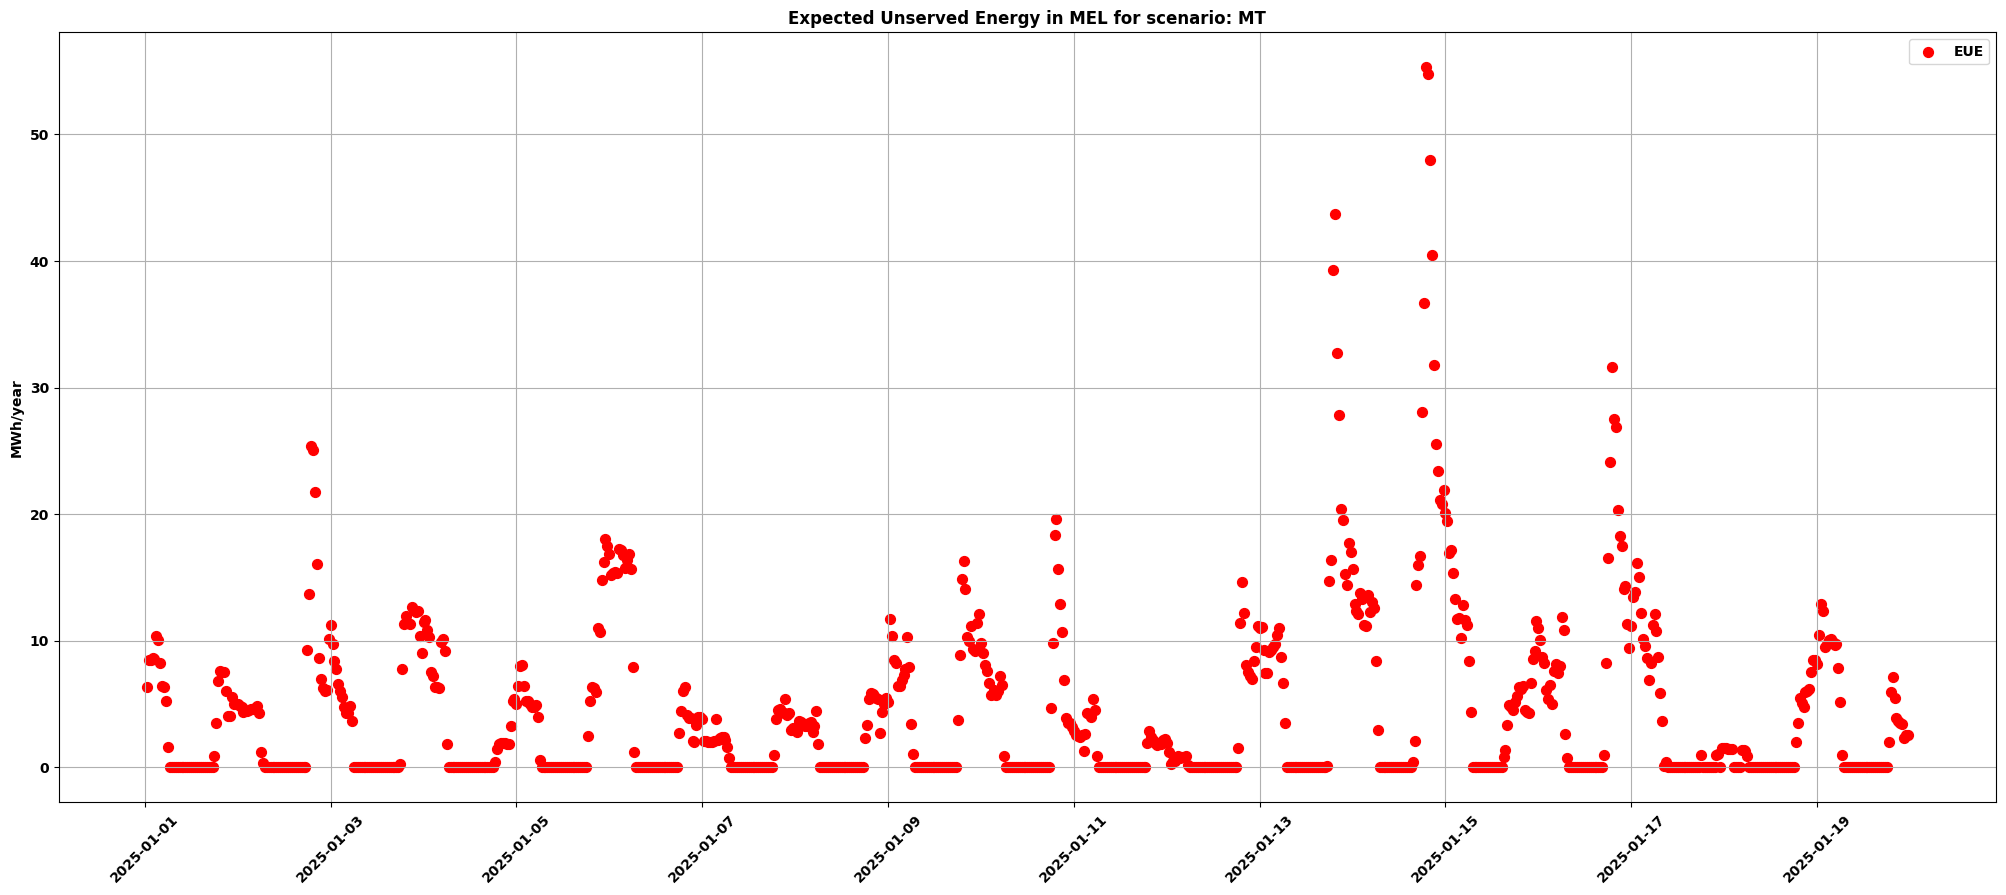

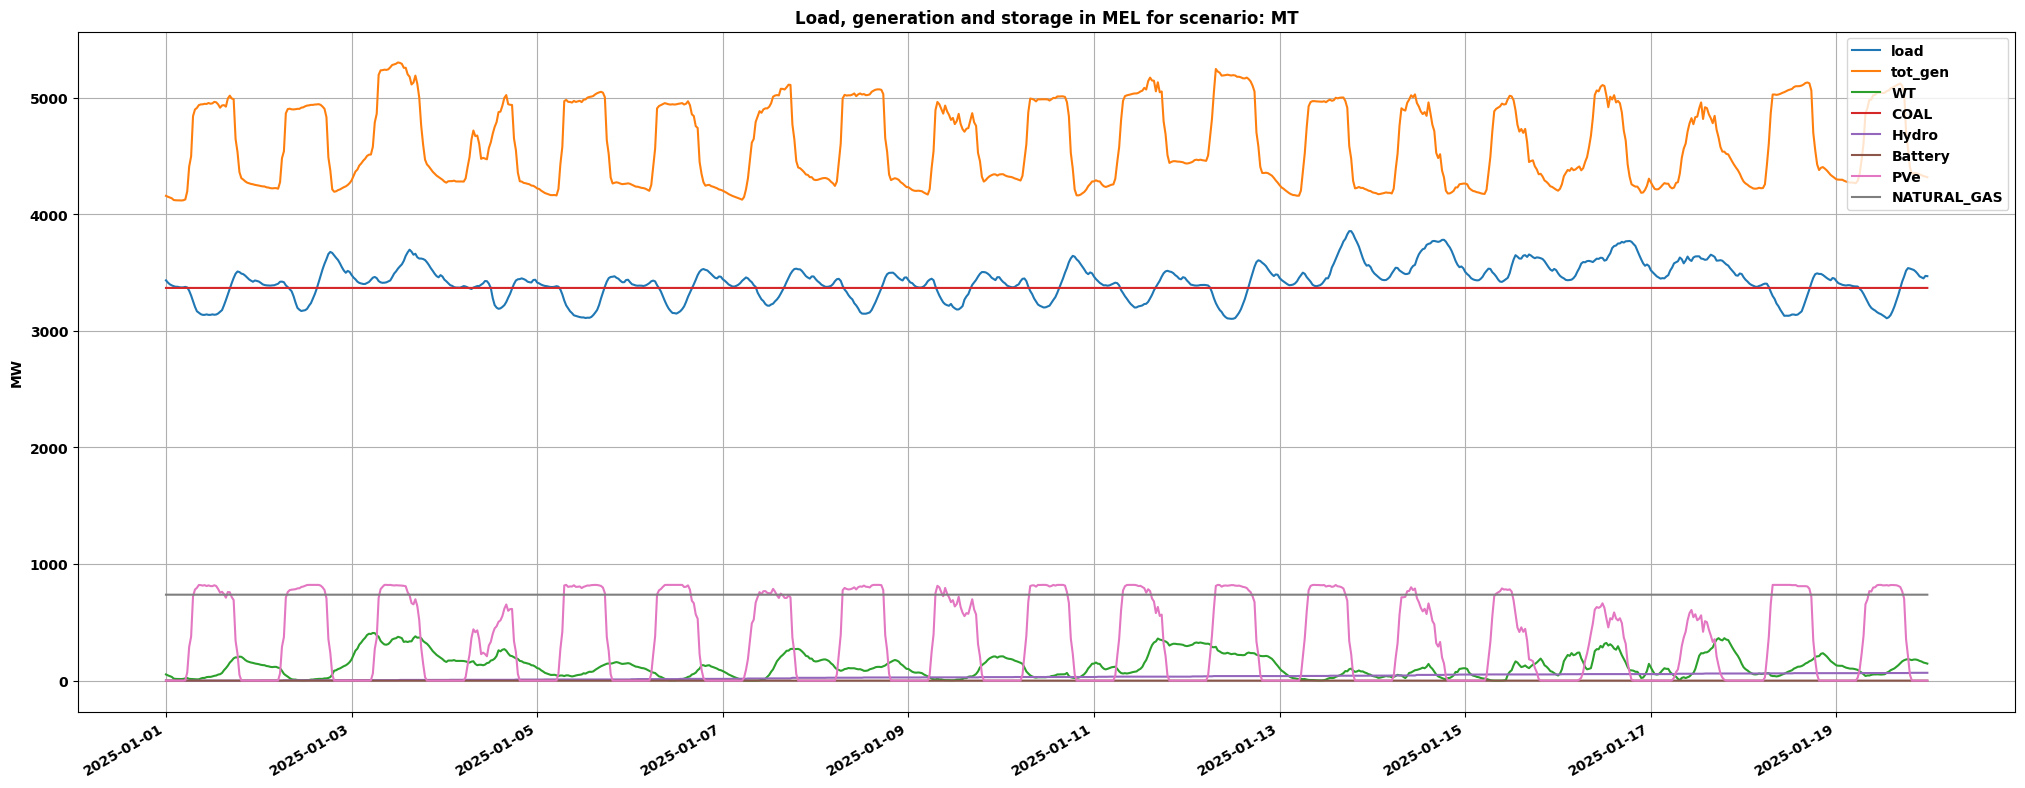

In [36]:
scenario = "MT"
target_region = "MEL"
st_date = '2025-01-1'
en_date = '2025-01-20'

print("Scenario chosen: ", scenario)
error_dict, shortfall_data = load_shortfall_error_data(scenario, IDIR)
plot_EUE_lgs(target_region, st_date, en_date, 
             shortfall_data, area_code_region, 
             scenario, IDIR, figsize)

In [10]:
# available battery in the regions [13,  6, 11,  4,  8,  9,  2,  5,  7]
#flow_for = flow_result(scenario, area_code_region)
#max_EUE = find_max_eue_regions(area_code_region, eue_df)
#print("Maximum Expected Unserved Energy detected :\n", max_EUE)
#print("flow name available for: ", flow_for.columns.tolist())


### The following Flow names are available; the target region will search all available Flow names. 

'SNSW-CNSW_mean_flow',
 'SNSW-WNV_mean_flow',
 'NNSW-CNSW_mean_flow',
 'NNSW-SQ_mean_flow',
 'NSA-CSA_mean_flow',
 'CNSW-SNW_mean_flow',
 'MEL-WNV_mean_flow',
 'MEL-SEV_mean_flow',
 'SQ-CQ_mean_flow',
 'CSA-WNV_mean_flow',
 'CSA-SESA_mean_flow',
 'TAS-SEV_mean_flow',
 'WNV-SESA_mean_flow',
 'NQ-CQ_mean_flow',
 'GG-CQ_mean_flow'


In [6]:
flow_for = flow_result(scenario, area_code_region, IDIR)

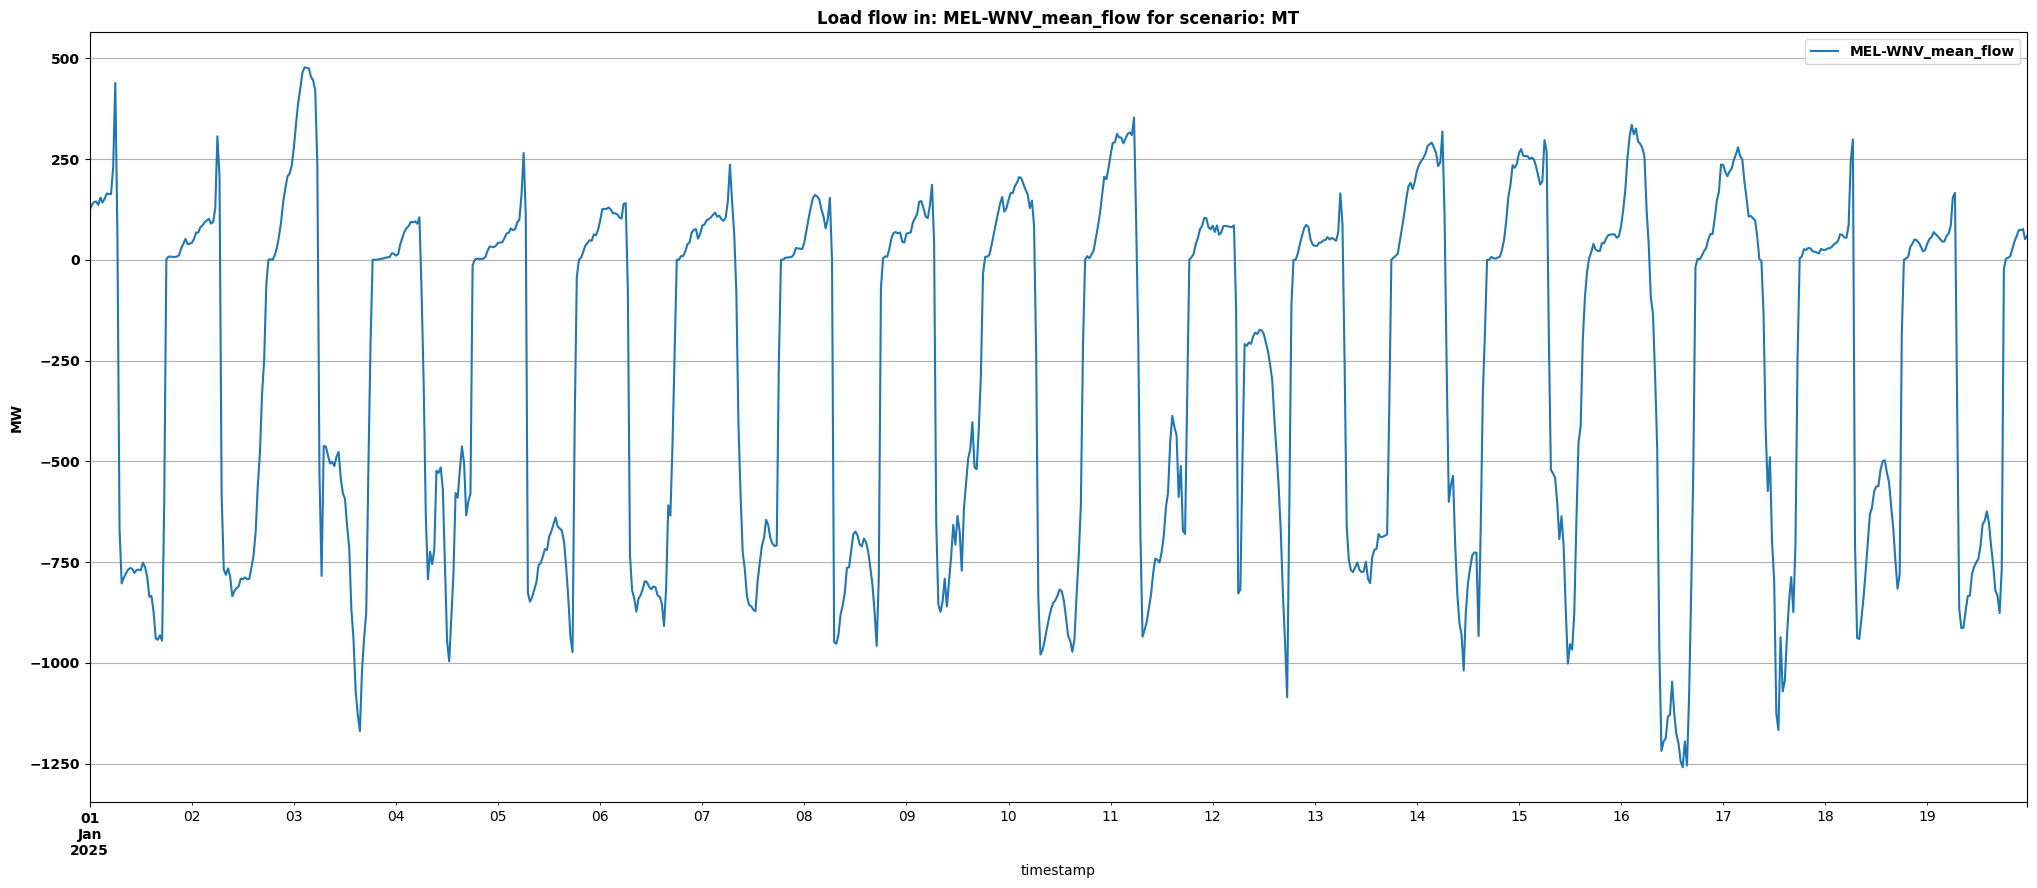

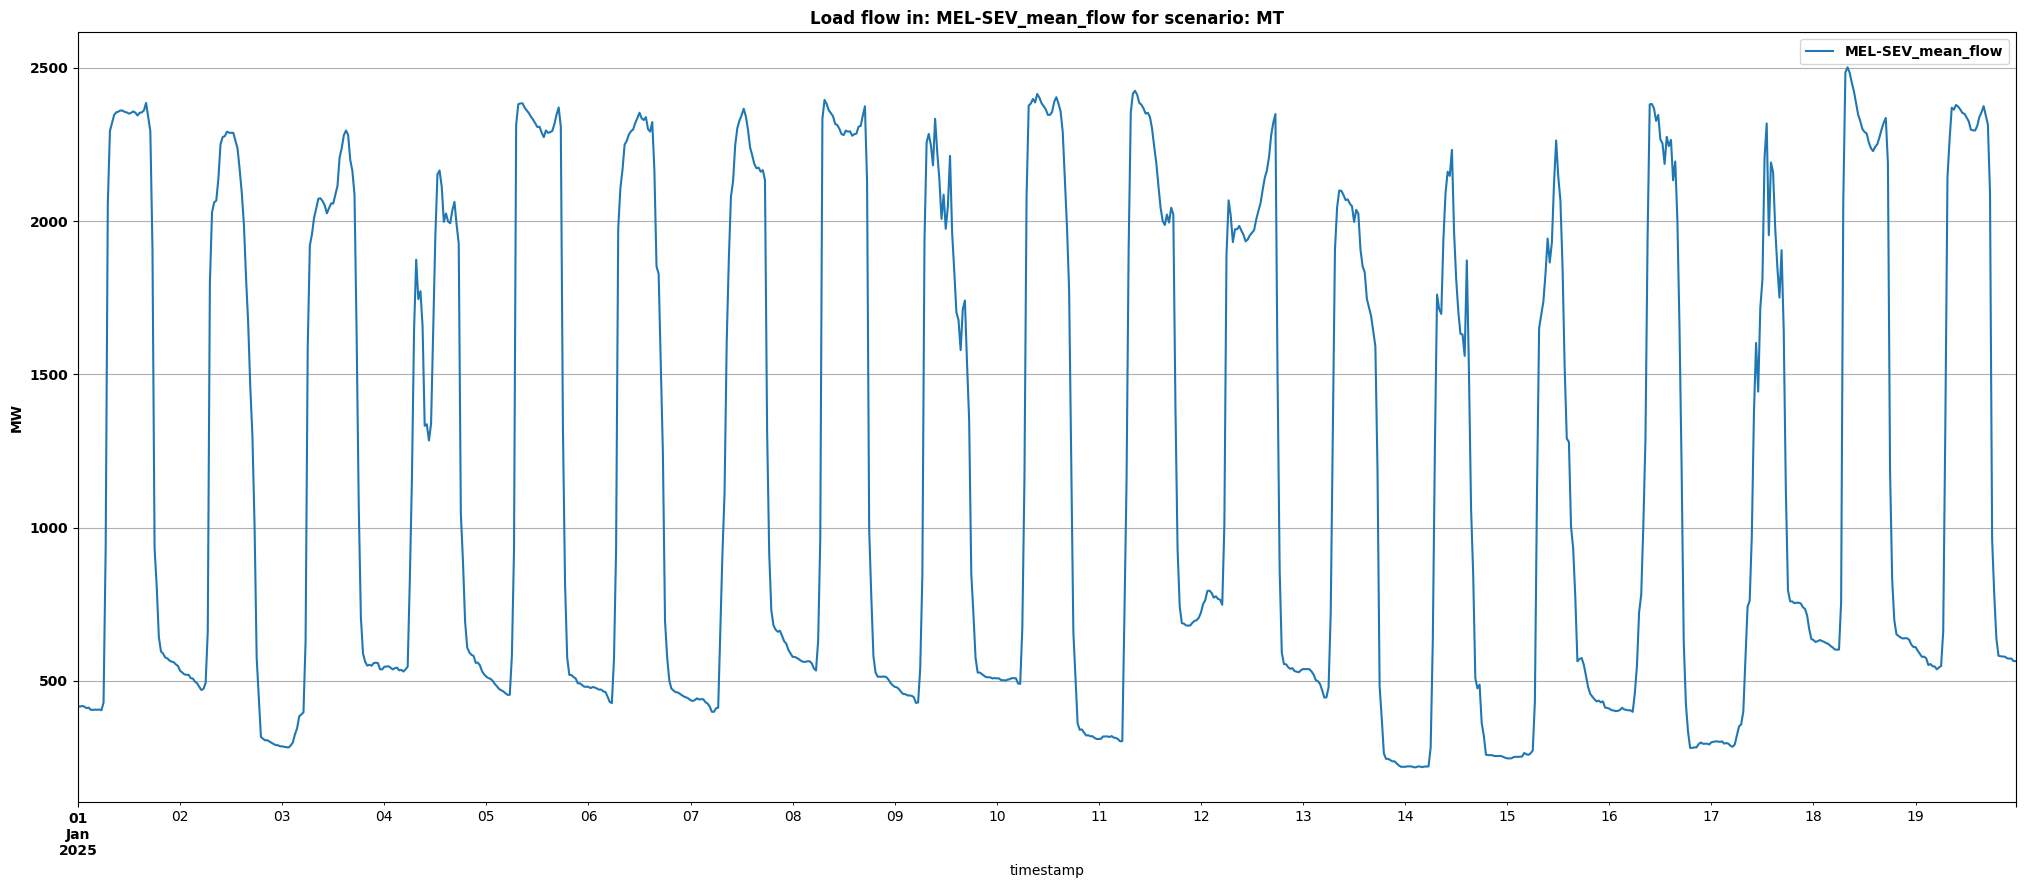

In [7]:
plot_flow(target_region, flow_for, st_date, en_date, scenario, figsize)